In [26]:
import pandas as pd

df = pd.read_csv("../data/Mall_Customers.csv")

df.rename(columns={"Genre": "Gender"}, inplace=True)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [27]:
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


In [28]:
# How many rows do we have?
# How many features?
# Are there missing values?
# What are the ranges of values?
# Any suspicious data?

print("Shape:")
print(df.shape)

print("\nInfo:")
df.info()

print("\nDescribe:")
print(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Shape:
(200, 5)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

Describe:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000

# Initial Data Exploration

## Dataset Overview

- **Rows:** 200
- **Features:** 5
- **Missing Values:** None

---

## Statistical Summary

### Age
- Mean: **38.85 years**
- Minimum: **18 years**
- Maximum: **70 years**

**Observation**
- Customers range from young adults to senior citizens.
- The average customer is around **39 years old**.
- Different age groups may exhibit different spending behaviors.

### Annual Income
- Mean: **60.56k$**
- Minimum: **15k$**
- Maximum: **137k$**

**Observation**
- Income varies significantly across customers.
- The highest income is over **9×** the lowest income.
- Annual income is expected to be an important feature for customer segmentation.

### Spending Score
- Mean: **50.2**
- Minimum: **1**
- Maximum: **99**

**Observation**
- Spending behavior varies widely among customers.
- This variation makes the Spending Score a valuable feature for K-Means clustering.

---

# Feature Selection

## Feature Relevance for Machine Learning

| Feature | Use for ML? | Reason |
|---------|:-----------:|--------|
| CustomerID | ❌ No | Unique identifier; does not contain meaningful information for clustering. |
| Gender | ✅ Maybe | May be useful depending on the clustering objective. |
| Age | ✅ Yes | Represents customer demographics. |
| Annual Income (k$) | ✅ Yes | Important feature for customer segmentation. |
| Spending Score (1–100) | ✅ Yes | Directly reflects customer spending behavior. |

### Final Observation

- Remove **CustomerID** before training since it is only an identifier.
- **Age**, **Annual Income**, and **Spending Score** are the primary numerical features for clustering.
- **Gender** can be included after encoding if demographic-based segmentation is desired.

# Exploratory Data Analysis (EDA) - Understanding Customer Characteristics

## Objective
Before applying any machine learning algorithm, it is important to understand the dataset. Exploratory Data Analysis (EDA) helps us identify patterns, detect anomalies, understand feature distributions, and gain business insights.

In this phase, we analyze the distributions of the following customer attributes:

- **Age**
- **Annual Income**
- **Spending Score**

---

## Why Histograms?

A histogram is used to visualize the distribution of a numerical feature.

It helps answer questions such as:

- Which age group has the most customers?
- What is the common income range?
- Are most customers high spenders or low spenders?
- Are there any unusual values or outliers?

Understanding these distributions allows us to make informed decisions before building machine learning models.

---

## Business Perspective

From a business standpoint, these visualizations help answer important questions:

- Which age group forms the majority of customers?
- What is the purchasing power of the customer base?
- How do customers differ in their spending behavior?

These insights are valuable for customer targeting, personalized marketing, and customer segmentation.

---

## Visualizations Performed

1. Age Distribution
2. Annual Income Distribution
3. Spending Score Distribution

The following code generates histograms for each of these features.

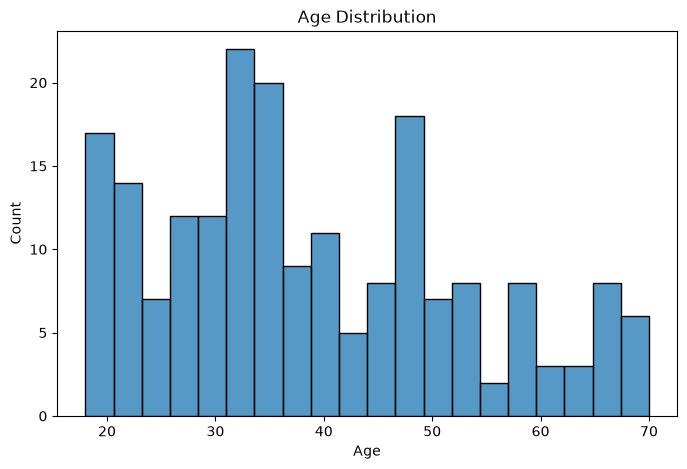

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")
plt.show()

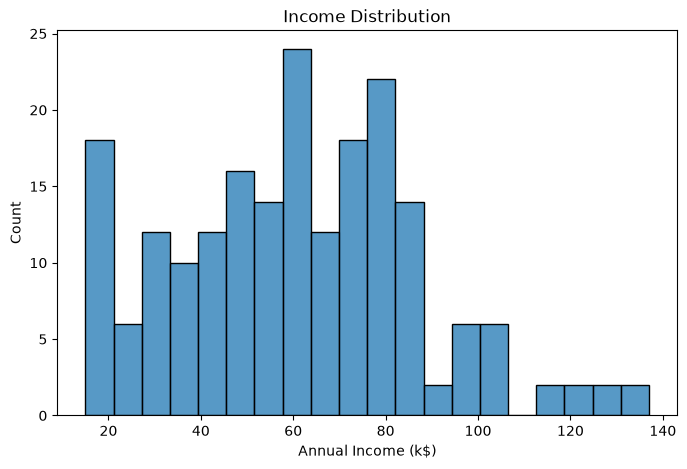

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Income Distribution")
plt.show()

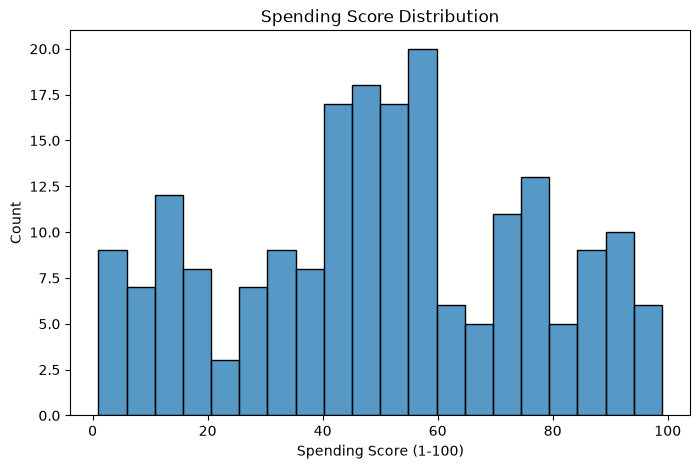

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")
plt.show()


## Observations

### Age Distribution
- Customers range from **18 to 70 years**.
- Most customers are between **25 and 40 years old**.
- The customer base mainly consists of young and middle-aged adults.

### Annual Income Distribution
- Annual income ranges from **15k$ to 137k$**.
- Most customers fall within the **40k$–80k$** income range.
- A small number of customers have significantly higher incomes.

### Spending Score Distribution
- Spending scores range from **1 to 99**.
- Customers exhibit a wide variety of spending behaviors.
- Some customers spend very little, while others are frequent and high-value shoppers.

---

## Conclusion

The dataset contains diverse customer profiles in terms of age, income, and spending behavior. This variation suggests that customers can potentially be grouped into meaningful segments. The next step is to analyze the relationship between these features using scatter plots before applying the K-Means clustering algorithm.

# Relationship Between Annual Income and Spending Score

## Objective

After understanding each feature individually, the next step is to examine how **Annual Income** and **Spending Score** are related.

A scatter plot is used to visualize the relationship between two numerical variables. In this plot:

- **X-axis:** Annual Income (k$)
- **Y-axis:** Spending Score (1–100)

Each point represents one customer.

---

## Why is this Visualization Important?

This visualization helps us identify whether customers naturally form groups based on their income and spending behavior.

If such groups exist, they can later be identified automatically using clustering algorithms such as **K-Means**.

---

## Business Significance

Understanding the relationship between income and spending enables businesses to:

- Identify premium customers.
- Detect low-value customers.
- Design personalized marketing campaigns.
- Improve customer retention strategies.
- Allocate marketing budgets more effectively.

The scatter plot provides the first indication that the customer data may contain natural clusters, making it an ideal candidate for clustering techniques.

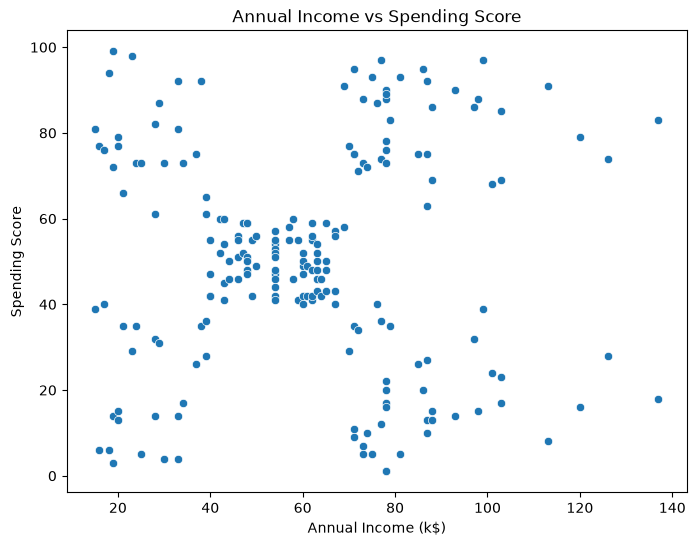

In [32]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    data=df
)

plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.show()

# Phase 10: Introduction to K-Means Clustering

## What is Clustering?

Clustering is an **unsupervised machine learning** technique used to group similar data points based on their characteristics.

Unlike supervised learning, clustering does not require labeled data. Instead, the algorithm discovers natural patterns and groups within the dataset.

---

## What is K-Means?

K-Means is one of the most popular clustering algorithms. It partitions the dataset into **K** clusters, where **K** is the number of groups we want the algorithm to identify.

Each cluster is represented by a **centroid**, which is the average position of all data points belonging to that cluster.

---

## Working of K-Means

The algorithm follows these steps:

1. Randomly initialize **K** centroids.
2. Assign each data point to the nearest centroid.
3. Compute the new centroid by taking the mean of all assigned points.
4. Repeat the assignment and update steps until the centroids no longer change significantly.

---

## Why K-Means for Customer Segmentation?

Customer segmentation aims to group customers with similar purchasing behavior.

K-Means helps businesses:

- Identify high-value customers.
- Discover customers with similar spending habits.
- Design targeted marketing campaigns.
- Improve customer retention and personalization.

In this project, K-Means will be used to identify natural customer segments based on **Annual Income** and **Spending Score**.

In [33]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

In [34]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Phase 11: Determining the Optimal Number of Clusters (Elbow Method)

## Objective

Before applying K-Means clustering, it is important to determine an appropriate value for **K**, the number of clusters.

Choosing too few clusters may combine distinct customer groups, while choosing too many clusters may create unnecessary segments.

---

## What is WCSS?

**Within-Cluster Sum of Squares (WCSS)** measures the total squared distance between each data point and the centroid of its assigned cluster.

A lower WCSS indicates that customers within a cluster are more similar to one another.

---

## Why the Elbow Method?

The Elbow Method computes WCSS for different values of **K**.

As the number of clusters increases:

- WCSS decreases because clusters become smaller.
- After a certain point, the improvement becomes minimal.

The point where the curve starts to flatten is called the **elbow**, and it represents a suitable choice for the number of clusters.

---

## Features Used

For customer segmentation, the following features are selected:

- Annual Income (k$)
- Spending Score (1–100)

These two variables capture customer purchasing behavior and are well suited for identifying meaningful customer segments.

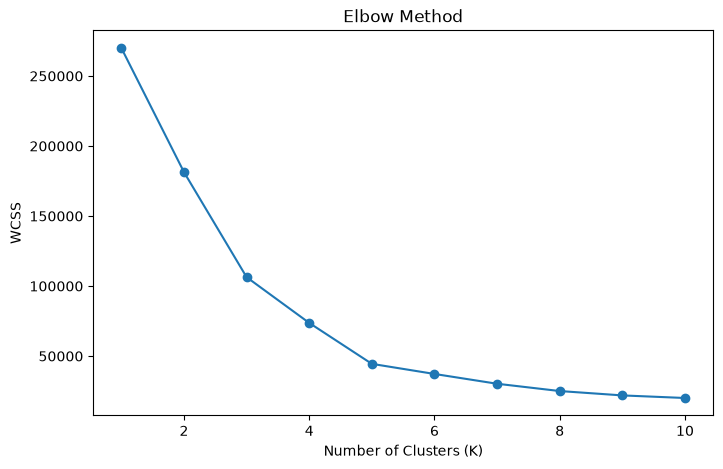

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()

# Interpretation of the Elbow Method

From the elbow curve, the WCSS decreases rapidly as the number of clusters increases from **1 to 5**.

After **K = 5**, the rate of decrease becomes much smaller, indicating that adding more clusters provides only marginal improvement.

Therefore, **5** is selected as the optimal number of clusters because it provides a good balance between cluster compactness and model simplicity.

Using five clusters also produces customer segments that are easier to interpret and utilize for business decision-making.

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10 #Runs K-Means with 10 different initial centroid placements and keeps the best solution, reducing the chance of a poor local optimum.
)

kmeans.fit(X) #train

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)","[[55.

In [37]:
df["Cluster"] = kmeans.labels_

In [38]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


# Phase 13: Visualizing Customer Segments

## Objective

After training the K-Means model, each customer is assigned to one of the five clusters.

The scatter plot below visualizes these customer segments using different colors. Each point represents one customer, while the red **X** markers represent the cluster centroids.

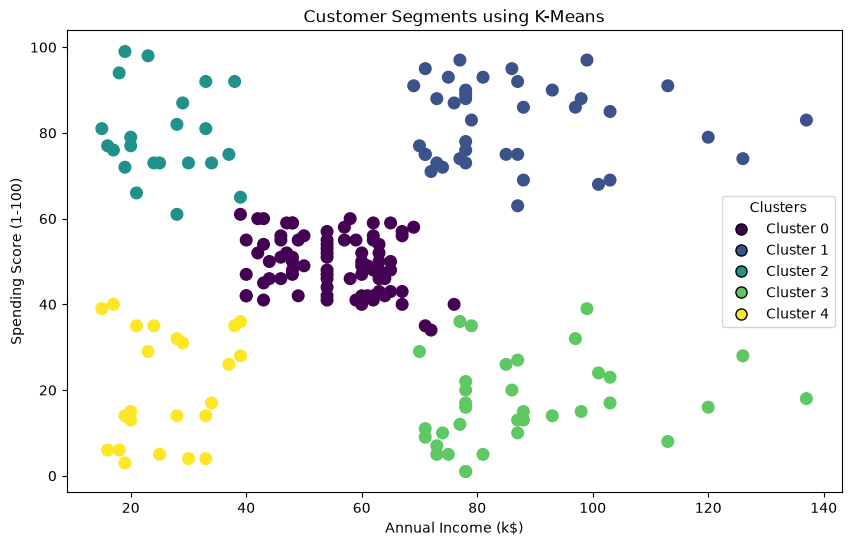

In [45]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.title("Customer Segments using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

# Add a legend showing cluster number -> color
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=f'Cluster {i}',
              markerfacecolor=plt.cm.viridis(i / (len(np.unique(df['Cluster'])) - 1 if len(np.unique(df['Cluster'])) > 1 else 1)),
              markeredgecolor='black', markersize=8)
    for i in range(len(np.unique(df['Cluster'])))
]
plt.legend(handles=legend_handles, title="Clusters")

plt.show()

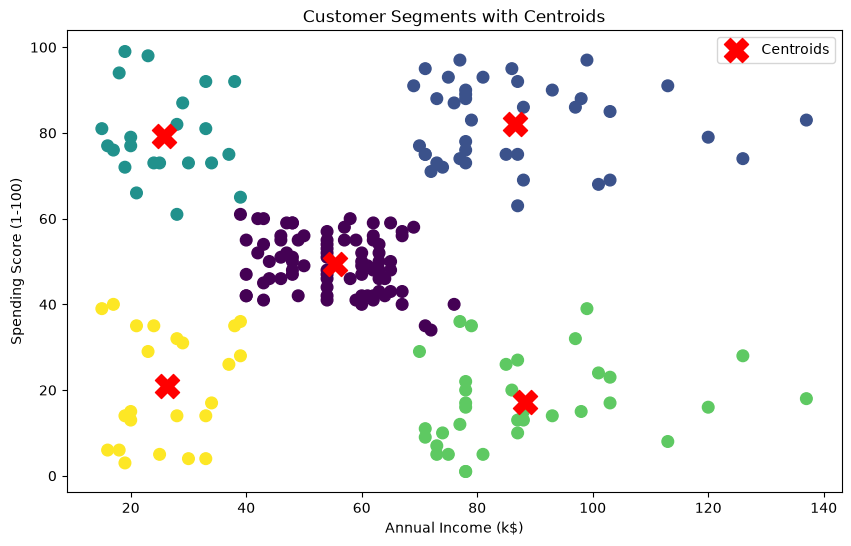

In [46]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"],
    c=df["Cluster"],
    cmap="viridis",
    s=70
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c="red",
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments with Centroids")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

## What is cluster_centers_?

When K-Means finishes, it stores the coordinates of the center of each cluster.

In [47]:
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]





## Interpretation

Customers belonging to the same cluster exhibit similar purchasing behavior based on:

- Annual Income
- Spending Score

The centroid represents the average customer profile for that segment.

Visualizing the clusters allows us to understand how customers are grouped and provides the foundation for business-driven customer segmentation strategies.

# Phase 14: Customer Segment Interpretation

## Objective

The K-Means algorithm assigns each customer to a cluster, but the cluster numbers themselves do not have any business meaning.

To make the results useful, we analyze the average characteristics of each cluster, including:

- Annual Income
- Spending Score
- Age

Based on these characteristics, descriptive names can be assigned to each customer segment.

These business-friendly labels help organizations understand customer behavior and design targeted marketing strategies.

In [48]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending Score (1-100)", "Age"]].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
0,55.296296,49.518519,42.716049
1,86.538462,82.128205,32.692308
2,25.727273,79.363636,25.272727
3,88.200000,17.114286,41.114286
4,26.304348,20.913043,45.217391


In [49]:
df["Cluster"].value_counts().sort_index()

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64



## Customer Segments

### Cluster 0 – Regular Customers
- Medium income
- Medium spending
- Largest customer group
- Suitable for loyalty programs and personalized promotions.

### Cluster 1 – Premium Customers
- High income
- High spending
- High-value customers contributing significant revenue.
- Best suited for VIP memberships and exclusive offers.

### Cluster 2 – Impulse Shoppers
- Low income
- High spending
- Young customers with strong purchasing behavior.
- Can be targeted through flash sales and trend-based marketing.

### Cluster 3 – Wealthy but Conservative Customers
- High income
- Low spending
- Customers with high purchasing power but low engagement.
- Opportunity for targeted promotions and personalized campaigns.

### Cluster 4 – Budget Customers
- Low income
- Low spending
- Price-sensitive customers.
- Suitable for discounts, coupons, and budget-friendly products.

---

## Business Conclusion

Customer segmentation enables businesses to understand different purchasing behaviors instead of treating all customers alike.

The insights obtained from clustering can support:

- Personalized marketing
- Customer retention strategies
- Product recommendations
- Resource allocation
- Revenue optimization